https://github.com/jibanCat/Akum-CL-SBI/blob/mfho/hbi-verification/hbi_verification/mcmc_tutorial.ipynb

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
plt.rcParams.update({"font.size": 12, "figure.figsize": (6, 4)})
np.random.seed(2807)
print("emcee", emcee.__version__, "| numpy", np.__version__)


emcee 3.1.6 | numpy 2.4.6


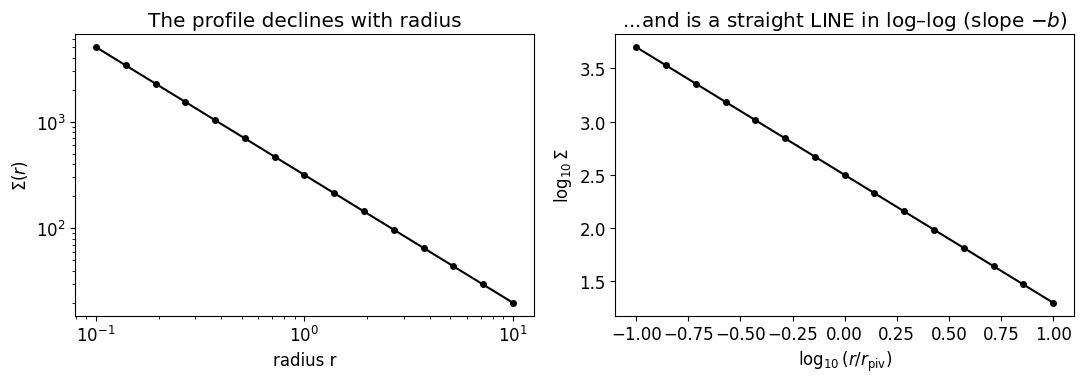

In [4]:
radii = np.logspace(-1, 1, 15)            # 15 radial bins, r = 0.1 .. 10 (e.g. arcmin or Mpc)
r_pivot = 1.0
log_r = np.log10(radii / r_pivot)         # the line's x-axis

def profile_model(theta):
    # log10 Sigma(r) = a - b log10(r/r_piv).  theta = (amplitude a, slope b).
    a, b = theta
    return a - b * log_r

a_true, b_true = 2.5, 1.2                  # one example cluster
log_sigma_true = profile_model((a_true, b_true))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(radii, 10**log_sigma_true, "k-o", ms=4)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("radius r"); ax[0].set_ylabel(r"$\Sigma(r)$")
ax[0].set_title("The profile declines with radius")
ax[1].plot(log_r, log_sigma_true, "k-o", ms=4)
ax[1].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$"); ax[1].set_ylabel(r"$\log_{10}\Sigma$")
ax[1].set_title("...and is a straight LINE in log–log (slope $-b$)")
plt.tight_layout(); plt.show()

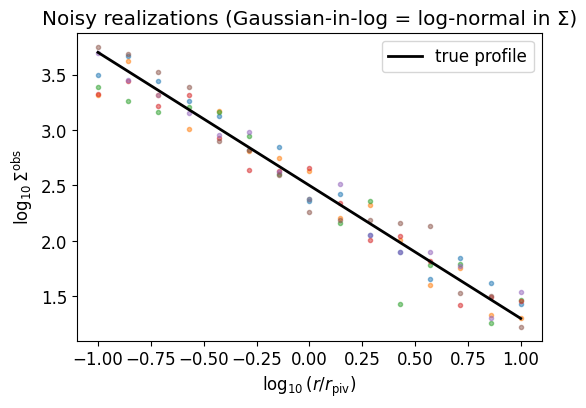

In [5]:
noise_dex = 0.15                                   # per-bin 1-sigma noise in log10 Sigma ("dex")
def observe(theta, sigma=noise_dex):
    # one noisy profile (a data VECTOR of length N_r)
    return profile_model(theta) + sigma * np.random.randn(len(radii))

plt.figure()
for _ in range(6):                                # several noisy realizations of the SAME cluster
    plt.plot(log_r, observe((a_true, b_true)), ".", alpha=0.5)
plt.plot(log_r, log_sigma_true, "k-", lw=2, label="true profile")
plt.xlabel(r"$\log_{10}(r/r_{\rm piv})$"); plt.ylabel(r"$\log_{10}\Sigma^{\rm obs}$")
plt.title("Noisy realizations (Gaussian-in-log = log-normal in Σ)"); plt.legend(); plt.show()

data_one = observe((a_true, b_true))               # the ONE cluster we will fit next

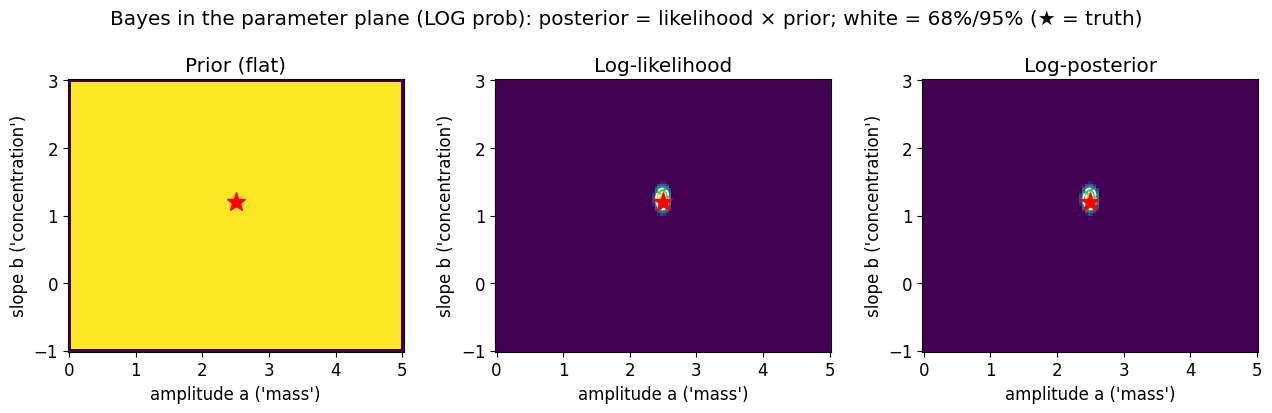

In [6]:
def log_likelihood(theta, d, sigma=noise_dex):
    resid = d - profile_model(theta)
    return -0.5 * np.sum(resid**2 / sigma**2)

A_LO, A_HI, B_LO, B_HI = 0.0, 5.0, -1.0, 3.0       # the flat-prior box for (a, b)
def log_prior(theta):
    a, b = theta
    return 0.0 if (A_LO < a < A_HI and B_LO < b < B_HI) else -np.inf

def log_posterior(theta, d, sigma=noise_dex):
    lp = log_prior(theta)
    return -np.inf if not np.isfinite(lp) else lp + log_likelihood(theta, d, sigma)

# Evaluate prior / likelihood / posterior on a grid over the (a,b) plane.
agrid = np.linspace(A_LO, A_HI, 120); bgrid = np.linspace(B_LO, B_HI, 120)
AA, BB = np.meshgrid(agrid, bgrid, indexing="ij")
model_cube = AA[..., None] - BB[..., None] * log_r          # predicted profile at every (a,b)
chi2 = np.sum((data_one - model_cube)**2 / noise_dex**2, axis=-1)
# Work in LOG probability -- the linear likelihood is far too sharply peaked to see as a color map.
loglike  = -0.5 * (chi2 - chi2.min())                       # log-likelihood (relative to its peak)
logprior = np.where((AA > A_LO) & (AA < A_HI) & (BB > B_LO) & (BB < B_HI), 0.0, -50.0)  # flat prior (log)
logpost  = loglike + logprior; logpost -= logpost.max()     # log posterior = log likelihood + log prior
levels = [-3.09, -1.15]                                     # 95% / 68% credible (Delta 2 lnL = 6.18, 2.30)

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
panels = [("Prior (flat)",   np.clip(logprior, -8, 0),               None),
          ("Log-likelihood", np.clip(loglike - loglike.max(), -8, 0), loglike - loglike.max()),
          ("Log-posterior",  np.clip(logpost, -8, 0),                 logpost)]
for axi, (title, shade, cont) in zip(ax, panels):
    axi.pcolormesh(AA, BB, shade, shading="auto", cmap="viridis")
    if cont is not None: axi.contour(AA, BB, cont, levels=levels, colors="white", linewidths=1.2)
    axi.plot(a_true, b_true, "r*", ms=14)
    axi.set_xlabel("amplitude a ('mass')"); axi.set_ylabel("slope b ('concentration')"); axi.set_title(title)
fig.suptitle("Bayes in the parameter plane (LOG prob): posterior = likelihood × prior; white = 68%/95% (★ = truth)")
plt.tight_layout(); plt.show()

   acceptance=0.71 | autocorr ~27 steps | ~2965 independent samples (want >> 1)


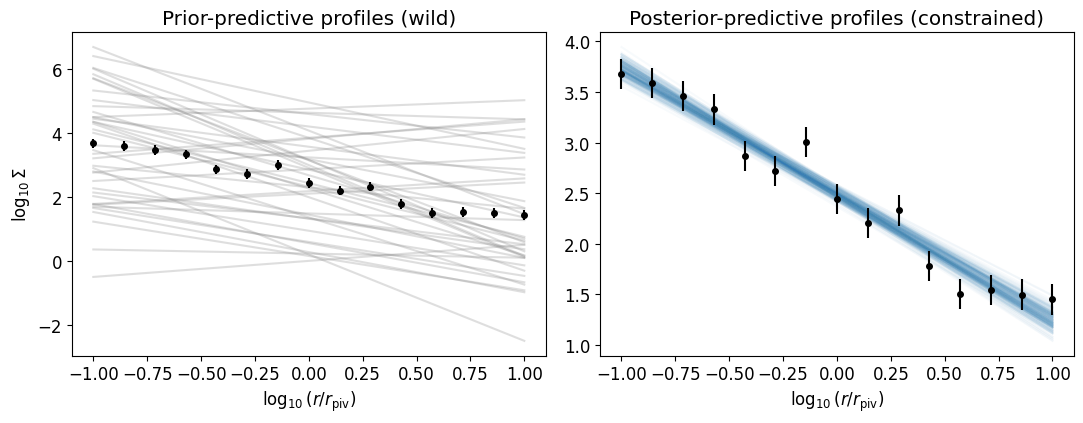

ONE cluster: posterior std on (a,b) = [0.039 0.063]  <- wide, from one noisy cluster


In [7]:
def run_mcmc(log_post, args, start, n_walkers=40, n_burn=500, n_steps=2000, verbose=True):
    # small reusable emcee wrapper -> flat samples (n_walkers*n_steps, n_dim)
    n_dim = len(start)
    p0 = start + 0.05 * np.random.randn(n_walkers, n_dim)
    s = emcee.EnsembleSampler(n_walkers, n_dim, log_post, args=args)
    state = s.run_mcmc(p0, n_burn, progress=False); s.reset(); s.run_mcmc(state, n_steps, progress=False)
    if verbose:
        # two cheap health checks: acceptance fraction, and autocorrelation time -> independent samples
        try: tau_ac = float(np.mean(s.get_autocorr_time(quiet=True)))
        except Exception: tau_ac = float("nan")
        ess = (n_walkers*n_steps/tau_ac) if tau_ac == tau_ac else float("nan")
        print("   acceptance=%.2f | autocorr ~%.0f steps | ~%.0f independent samples (want >> 1)"
              % (s.acceptance_fraction.mean(), tau_ac, ess))
    return s.get_chain(flat=True)

samples_one = run_mcmc(log_posterior, args=(data_one,), start=np.array([a_true, b_true]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
# prior-predictive: random (a,b) from the flat box -> profiles all over the place
for _ in range(40):
    th = [np.random.uniform(A_LO, A_HI), np.random.uniform(B_LO, B_HI)]
    ax[0].plot(log_r, profile_model(th), color="tab:gray", alpha=0.25)
ax[0].errorbar(log_r, data_one, yerr=noise_dex, fmt="ko", ms=4)
ax[0].set_title("Prior-predictive profiles (wild)"); ax[0].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$"); ax[0].set_ylabel(r"$\log_{10}\Sigma$")
# posterior-predictive: profiles from posterior samples -> tight bundle through the data
for th in samples_one[np.random.randint(len(samples_one), size=200)]:
    ax[1].plot(log_r, profile_model(th), color="tab:blue", alpha=0.03)
ax[1].errorbar(log_r, data_one, yerr=noise_dex, fmt="ko", ms=4)
ax[1].set_title("Posterior-predictive profiles (constrained)"); ax[1].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$")
plt.tight_layout(); plt.show()
print("ONE cluster: posterior std on (a,b) =", samples_one.std(axis=0).round(3), " <- wide, from one noisy cluster")

TRUE hyper-parameters:  population mean = [2.5 1.2]   intrinsic scatter = [0.25 0.3 ]


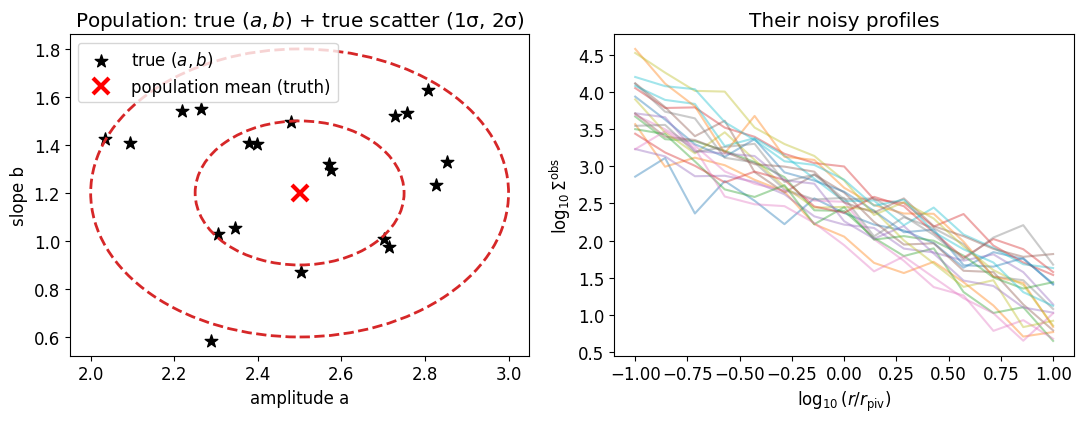

In [8]:
n_clusters = 20
mu_pop = np.array([2.50, 1.20])      # TRUE population mean of (amplitude, slope)
s_pop  = np.array([0.25, 0.30])      # TRUE intrinsic scatter (cluster-to-cluster)
print("TRUE hyper-parameters:  population mean =", mu_pop, "  intrinsic scatter =", s_pop)

theta_true = mu_pop + s_pop * np.random.randn(n_clusters, 2)         # each cluster's true (a,b)
profiles   = np.array([profile_model(theta_true[j]) + noise_dex*np.random.randn(len(radii))
                       for j in range(n_clusters)])                  # their noisy profiles

from matplotlib.patches import Ellipse
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].scatter(theta_true[:, 0], theta_true[:, 1], c="k", marker="*", s=90, label="true $(a,b)$")
for nsig in (1, 2):                       # show the TRUE population scatter as 1-sigma & 2-sigma ellipses
    ax[0].add_patch(Ellipse(mu_pop, 2*nsig*s_pop[0], 2*nsig*s_pop[1], fill=False, ls="--", color="tab:red", lw=2))
ax[0].plot(mu_pop[0], mu_pop[1], "rx", ms=12, mew=3, label="population mean (truth)")
ax[0].set_xlabel("amplitude a"); ax[0].set_ylabel("slope b")
ax[0].set_title("Population: true $(a,b)$ + true scatter (1σ, 2σ)"); ax[0].legend()
for p in profiles:
    ax[1].plot(log_r, p, alpha=0.4)
ax[1].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$"); ax[1].set_ylabel(r"$\log_{10}\Sigma^{\rm obs}$"); ax[1].set_title("Their noisy profiles")
plt.tight_layout(); plt.show()

In [9]:
median_profile = np.median(profiles, axis=0)
sigma_tilde_sq = (np.pi/2) * noise_dex**2 / n_clusters
def with_prior(loglike):
    return lambda th: loglike(th) if np.isfinite(log_prior(th)) else -np.inf

ll_JtF   = lambda th: -0.5 * np.sum((median_profile - profile_model(th))**2 / sigma_tilde_sq)
ll_FtJ   = lambda th: -(1/(2*n_clusters)) * np.sum((profiles - profile_model(th))**2 / noise_dex**2)
ll_joint = lambda th: -0.5 * np.sum((profiles - profile_model(th))**2 / noise_dex**2)

samp_JtF   = run_mcmc(with_prior(ll_JtF),   args=(), start=mu_pop)
samp_FtJ   = run_mcmc(with_prior(ll_FtJ),   args=(), start=mu_pop)
samp_joint = run_mcmc(with_prior(ll_joint), args=(), start=mu_pop)
w = lambda s: s[:, 0].std()      # uncertainty on amplitude a
print("\nposterior width on amplitude a:")
print("  JtF=%.4f   FtJ(paper)=%.4f   correct joint=%.4f" % (w(samp_JtF), w(samp_FtJ), w(samp_joint)))
print("  FtJ/JtF = %.2f (sqrt(2Nc/pi)=%.2f) | FtJ/joint = %.2f (sqrt(Nc)=%.2f)"
      % (w(samp_FtJ)/w(samp_JtF), np.sqrt(2*n_clusters/np.pi), w(samp_FtJ)/w(samp_joint), np.sqrt(n_clusters)))

   acceptance=0.71 | autocorr ~28 steps | ~2884 independent samples (want >> 1)
   acceptance=0.71 | autocorr ~29 steps | ~2781 independent samples (want >> 1)
   acceptance=0.71 | autocorr ~28 steps | ~2819 independent samples (want >> 1)

posterior width on amplitude a:
  JtF=0.0111   FtJ(paper)=0.0387   correct joint=0.0088
  FtJ/JtF = 3.49 (sqrt(2Nc/pi)=3.57) | FtJ/joint = 4.38 (sqrt(Nc)=4.47)


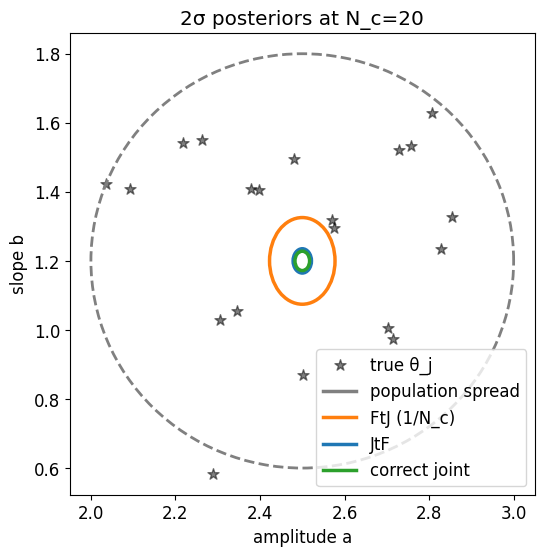

In [10]:
from matplotlib.patches import Ellipse
def cov_ellipse(ax, c, cov, n=2, **kw):
    v, V = np.linalg.eigh(cov); o = v.argsort()[::-1]; v, V = v[o], V[:, o]
    ang = np.degrees(np.arctan2(V[1, 0], V[0, 0])); ax.add_patch(Ellipse(c, *(2*n*np.sqrt(v)), angle=ang, fill=False, **kw))
XtX_inv = np.linalg.inv((np.column_stack([np.ones_like(log_r), -log_r])).T @ np.column_stack([np.ones_like(log_r), -log_r]))
fig, ax = plt.subplots(figsize=(6, 6)); c = mu_pop
ax.scatter(theta_true[:, 0], theta_true[:, 1], marker="*", s=70, color="k", alpha=0.5, label="true θ_j")
cov_ellipse(ax, c, np.diag(s_pop**2), color="gray", lw=2, ls="--"); cov_ellipse(ax, c, noise_dex**2*XtX_inv, color="tab:orange", lw=2.5)
cov_ellipse(ax, c, sigma_tilde_sq*XtX_inv, color="tab:blue", lw=2.5); cov_ellipse(ax, c, noise_dex**2/n_clusters*XtX_inv, color="tab:green", lw=2.5)
for lab, col in [("population spread", "gray"), ("FtJ (1/N_c)", "tab:orange"), ("JtF", "tab:blue"), ("correct joint", "tab:green")]:
    ax.plot([], [], color=col, lw=2.5, label=lab)
ax.set_xlabel("amplitude a"); ax.set_ylabel("slope b"); ax.set_title("2σ posteriors at N_c=20"); ax.legend(); plt.show()

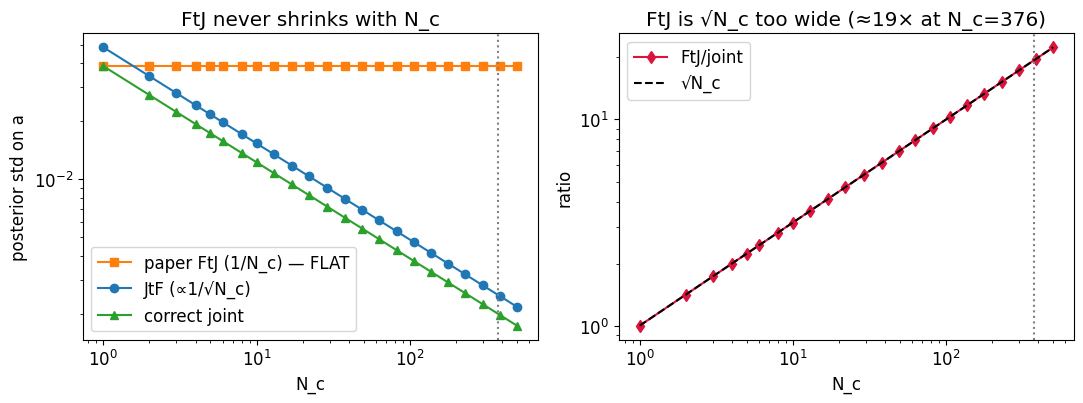

In [11]:
w0 = np.sqrt(XtX_inv[0, 0]); Nc = np.unique(np.round(np.logspace(0, 2.7, 25)).astype(int))
W_JtF = np.sqrt(np.pi/2)*noise_dex*w0/np.sqrt(Nc); W_jnt = noise_dex*w0/np.sqrt(Nc); W_FtJ = noise_dex*w0*np.ones_like(Nc, float)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].loglog(Nc, W_FtJ, "s-", color="tab:orange", label="paper FtJ (1/N_c) — FLAT"); ax[0].loglog(Nc, W_JtF, "o-", color="tab:blue", label="JtF (∝1/√N_c)")
ax[0].loglog(Nc, W_jnt, "^-", color="tab:green", label="correct joint"); ax[0].axvline(376, color="gray", ls=":")
ax[0].set_xlabel("N_c"); ax[0].set_ylabel("posterior std on a"); ax[0].set_title("FtJ never shrinks with N_c"); ax[0].legend()
ax[1].loglog(Nc, W_FtJ/W_jnt, "d-", color="crimson", label="FtJ/joint"); ax[1].loglog(Nc, np.sqrt(Nc), "k--", label="√N_c"); ax[1].axvline(376, color="gray", ls=":")
ax[1].set_xlabel("N_c"); ax[1].set_ylabel("ratio"); ax[1].set_title("FtJ is √N_c too wide (≈19× at N_c=376)"); ax[1].legend(); plt.tight_layout(); plt.show()

In [17]:
print((meas["JtF"]))

[np.float64(0.020928021566780922), np.float64(0.011013359788231038), np.float64(0.005361928109412435)]


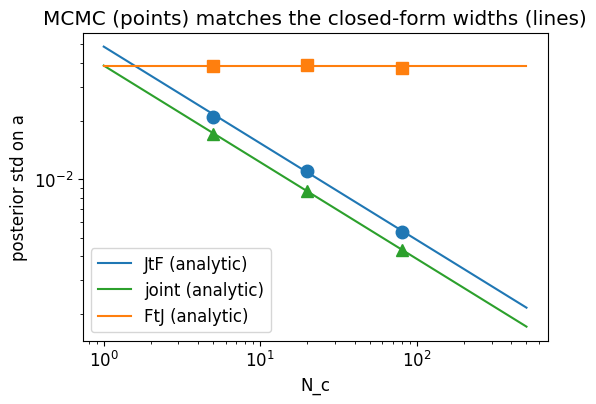

MCMC widths land on the analytic curves -> the instant N_c-sweep is trustworthy.


In [14]:
# VALIDATION: overlay the MEASURED MCMC widths (at a few N_c) on the analytic curves above.
meas = {"JtF": [], "joint": [], "FtJ": []}; Nc_test = [5, 20, 80]
for nc in Nc_test:
    th = mu_pop + s_pop*np.random.randn(nc, 2)
    pr = np.array([profile_model(th[j]) + noise_dex*np.random.randn(len(radii)) for j in range(nc)])
    mdp = np.median(pr, axis=0); st2 = (np.pi/2)*noise_dex**2/nc
    fj = run_mcmc(with_prior(lambda t, mdp=mdp, st2=st2: -0.5*np.sum((mdp-profile_model(t))**2/st2)), (), mu_pop, n_burn=200, n_steps=600, verbose=False)
    jn = run_mcmc(with_prior(lambda t, pr=pr: -0.5*np.sum((pr-profile_model(t))**2/noise_dex**2)), (), mu_pop, n_burn=200, n_steps=600, verbose=False)
    ft = run_mcmc(with_prior(lambda t, pr=pr, nc=nc: -(1/(2*nc))*np.sum((pr-profile_model(t))**2/noise_dex**2)), (), mu_pop, n_burn=200, n_steps=600, verbose=False)
    meas["JtF"].append(fj[:, 0].std()); meas["joint"].append(jn[:, 0].std()); meas["FtJ"].append(ft[:, 0].std())
plt.figure()
plt.loglog(Nc, W_JtF, "-", color="tab:blue", label="JtF (analytic)");  plt.loglog(Nc_test, meas["JtF"], "o", ms=9, color="tab:blue")
plt.loglog(Nc, W_jnt, "-", color="tab:green", label="joint (analytic)"); plt.loglog(Nc_test, meas["joint"], "^", ms=9, color="tab:green")
plt.loglog(Nc, W_FtJ, "-", color="tab:orange", label="FtJ (analytic)");  plt.loglog(Nc_test, meas["FtJ"], "s", ms=9, color="tab:orange")
plt.xlabel("N_c"); plt.ylabel("posterior std on a"); plt.title("MCMC (points) matches the closed-form widths (lines)"); plt.legend(); plt.show()
print("MCMC widths land on the analytic curves -> the instant N_c-sweep is trustworthy.")

The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 18;
tau: [26.32989931 25.41489634]


   acceptance=0.72 | autocorr ~26 steps | ~1391 independent samples (want >> 1)


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 18;
tau: [26.58105892 27.84248487]


   acceptance=0.72 | autocorr ~27 steps | ~1323 independent samples (want >> 1)


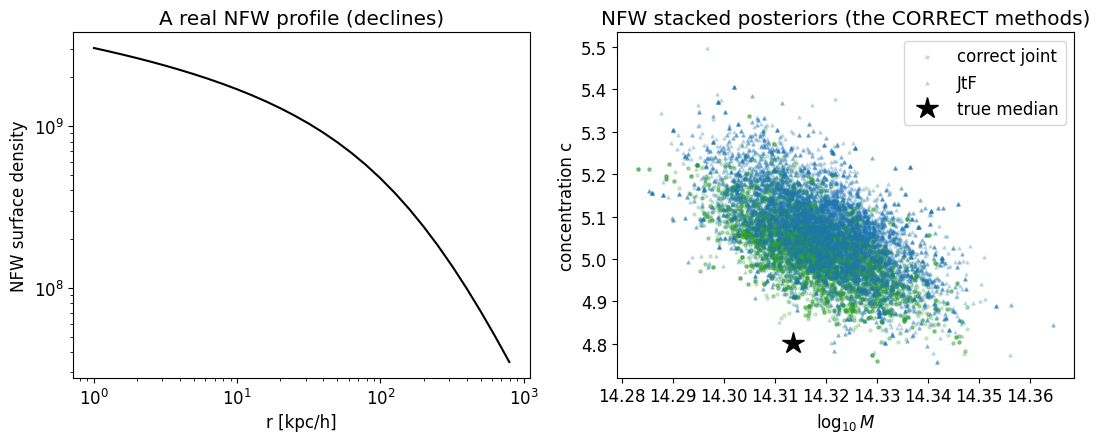

NFW stacked widths log10M:  JtF=0.011  correct-joint=0.009  (the buggy 1/N_c FtJ would be ~sqrt(N_c) wider)


In [13]:
try:
    from colossus.cosmology import cosmology; from colossus.halo import profile_nfw
    cosmology.setCosmology("planck18"); nfw_r = 10**np.arange(0, 3, 0.1)
    def nfw_logSigma(theta):                         # theta = (log10 mass, concentration)
        h = profile_nfw.NFWProfile(M=10**theta[0], c=theta[1], z=0.0, mdef="vir")
        return np.log10(h.surfaceDensity(nfw_r))
    th0 = np.array([14.3, 5.0]); dex = 0.10
    # population of NFW clusters + noisy profiles
    Nc2 = 20; m = 14.3 + 0.10*np.random.randn(Nc2); cc = 5.0 + 0.7*np.random.randn(Nc2)
    P = np.array([nfw_logSigma([m[j], cc[j]]) + dex*np.random.randn(len(nfw_r)) for j in range(Nc2)])
    med = np.median(P, axis=0); st2 = (np.pi/2)*dex**2/Nc2
    inb = lambda t: 13.5 < t[0] < 15 and 1 < t[1] < 12
    lj = lambda t: (-0.5*np.sum((nfw_logSigma(t)-med)**2/st2)) if inb(t) else -np.inf            # JtF (median stack)
    lc = lambda t: (-0.5*np.sum((nfw_logSigma(t)[None]-P)**2/dex**2)) if inb(t) else -np.inf      # CORRECT joint (sum)
    s_j = run_mcmc(lj, args=(), start=th0, n_walkers=40, n_burn=300, n_steps=900)
    s_c = run_mcmc(lc, args=(), start=th0, n_walkers=40, n_burn=300, n_steps=900)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
    ax[0].plot(nfw_r, 10**nfw_logSigma(th0), "k-"); ax[0].set_xscale("log"); ax[0].set_yscale("log")
    ax[0].set_xlabel("r [kpc/h]"); ax[0].set_ylabel("NFW surface density"); ax[0].set_title("A real NFW profile (declines)")
    ax[1].scatter(s_c[::5, 0], s_c[::5, 1], s=5, alpha=0.2, marker="o", color="tab:green", label="correct joint")
    ax[1].scatter(s_j[::5, 0], s_j[::5, 1], s=5, alpha=0.2, marker="^", color="tab:blue", label="JtF")
    ax[1].plot(np.median(m), np.median(cc), "k*", ms=16, label="true median")
    ax[1].set_xlabel(r"$\log_{10} M$"); ax[1].set_ylabel("concentration c"); ax[1].set_title("NFW stacked posteriors (the CORRECT methods)"); ax[1].legend()
    plt.tight_layout(); plt.show()
    print("NFW stacked widths log10M:  JtF=%.3f  correct-joint=%.3f  (the buggy 1/N_c FtJ would be ~sqrt(N_c) wider)"
          % (s_j[:, 0].std(), s_c[:, 0].std()))
except Exception as e:
    print("Colossus not available; skipping NFW:", e)

In [14]:
# ---------- 1-D warm-up ----------
mu_w, tau_w, sig_w = 2.50, 0.25, 0.40                    # truth + measurement noise
N_w = 200                                                 # 200 clusters
a_true_w = mu_w + tau_w * np.random.randn(N_w)            # latent
d_w      = a_true_w + sig_w * np.random.randn(N_w)        # one observation per cluster

# per-cluster posterior is exactly N(d_j, sig_w^2)  ->  S=4000 samples each
S_w = 4000
post_w = d_w[:, None] + sig_w * np.random.randn(N_w, S_w)   # shape (N_c, S)

# Attempt 1: naive pool of ALL samples
tau_pool_w = post_w.ravel().std()
# Attempt 2: OLS on per-cluster posterior means (= d_j here)
tau_ols_w  = post_w.mean(axis=1).std()
# Attempt 3: importance-sampling recycle -- same hyper_logpost as below, closed-form here:
#   marginal evidence: p(d_j | mu, tau) = N(d_j; mu, tau^2 + sig_w^2)
mu_grid_w  = np.linspace(mu_w-0.25, mu_w+0.25, 80)
tau_grid_w = np.linspace(0.02, 0.60, 120)
mu_g, tau_g = np.meshgrid(mu_grid_w, tau_grid_w, indexing="ij")
var_pred = tau_g**2 + sig_w**2
logL = -0.5*np.sum(((d_w[:,None,None]-mu_g)**2)/var_pred + np.log(var_pred), axis=0)
logL -= logL.max(); P = np.exp(logL); P /= P.sum()
tau_post = P.sum(axis=0); mu_post = P.sum(axis=1)
tau_rcy_w  = float((tau_grid_w * tau_post).sum())
tau_rcy_sd = float(np.sqrt(((tau_grid_w - tau_rcy_w)**2 * tau_post).sum()))

print("1-D warm-up (truth: mu=%.2f, tau=%.2f, sigma_obs=%.2f, N_c=%d):" % (mu_w, tau_w, sig_w, N_w))
print("  Attempt 1 naive pool  : tau = %.3f                 (expected sqrt(tau^2+2 sig^2) = %.3f)" % (tau_pool_w, np.sqrt(tau_w**2 + 2*sig_w**2)))
print("  Attempt 2 OLS centers : tau = %.3f                 (expected sqrt(tau^2 +   sig^2) = %.3f)" % (tau_ols_w, np.sqrt(tau_w**2 +   sig_w**2)))
print("  Attempt 3 recycle (IS): tau = %.3f +/- %.3f      <- brackets truth %.2f cleanly" % (tau_rcy_w, tau_rcy_sd, tau_w))
print("  separation OLS<->recycle:  %.1f sigma" % (abs(tau_ols_w-tau_rcy_w)/tau_rcy_sd))

1-D warm-up (truth: mu=2.50, tau=0.25, sigma_obs=0.40, N_c=200):
  Attempt 1 naive pool  : tau = 0.617                 (expected sqrt(tau^2+2 sig^2) = 0.618)
  Attempt 2 OLS centers : tau = 0.470                 (expected sqrt(tau^2 +   sig^2) = 0.472)
  Attempt 3 recycle (IS): tau = 0.247 +/- 0.048      <- brackets truth 0.25 cleanly
  separation OLS<->recycle:  4.7 sigma


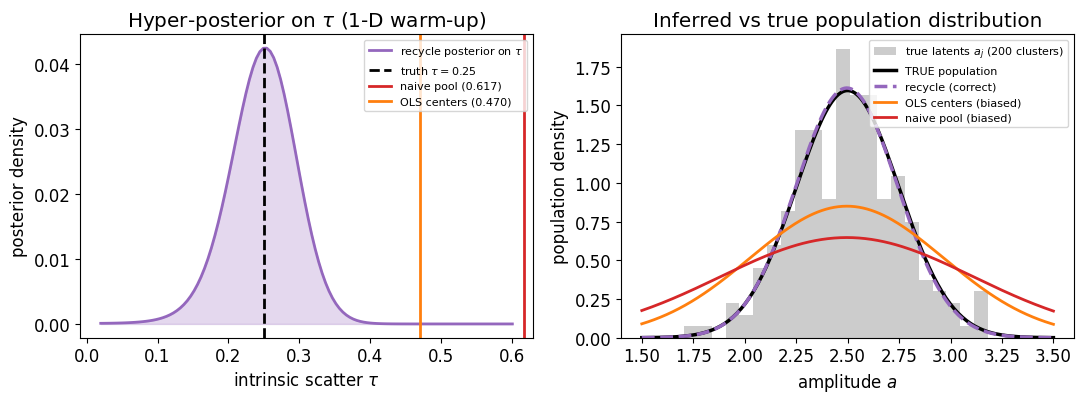

In [15]:
# Visualise: hyper-posterior on (mu, tau) with the three point estimates as vertical lines
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(tau_grid_w, tau_post, color="tab:purple", lw=2, label="recycle posterior on $\\tau$")
ax[0].fill_between(tau_grid_w, 0, tau_post, color="tab:purple", alpha=0.25)
ax[0].axvline(tau_w,     color="k",          ls="--", lw=2, label="truth $\\tau=0.25$")
ax[0].axvline(tau_pool_w, color="tab:red",    lw=2, label=f"naive pool ({tau_pool_w:.3f})")
ax[0].axvline(tau_ols_w,  color="tab:orange", lw=2, label=f"OLS centers ({tau_ols_w:.3f})")
ax[0].set_xlabel(r"intrinsic scatter $\tau$"); ax[0].set_ylabel("posterior density"); ax[0].set_title("Hyper-posterior on $\\tau$ (1-D warm-up)"); ax[0].legend(fontsize=8)

# Inferred population distribution vs the actual latent a_j
xx = np.linspace(mu_w - 4*tau_w, mu_w + 4*tau_w, 200)
gauss = lambda x, m, s: np.exp(-0.5*((x-m)/s)**2) / (s*np.sqrt(2*np.pi))
ax[1].hist(a_true_w, bins=22, density=True, color="0.8", label=f"true latents $a_j$ ({N_w} clusters)")
ax[1].plot(xx, gauss(xx, mu_w,        tau_w),     "k-",  lw=2.5, label=r"TRUE population")
ax[1].plot(xx, gauss(xx, d_w.mean(),  tau_rcy_w), "--",  color="tab:purple", lw=2.5, label="recycle (correct)")
ax[1].plot(xx, gauss(xx, d_w.mean(),  tau_ols_w), "-",   color="tab:orange", lw=2, label="OLS centers (biased)")
ax[1].plot(xx, gauss(xx, d_w.mean(),  tau_pool_w),"-",   color="tab:red",    lw=2, label="naive pool (biased)")
ax[1].set_xlabel("amplitude $a$"); ax[1].set_ylabel("population density"); ax[1].set_title("Inferred vs true population distribution"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [16]:
# Run the per-cluster fit for every cluster in the population (§4 made `profiles`).
# We deliberately add EXTRA noise here so individual-cluster posteriors are wide -- otherwise the
# per-cluster scatter sigma_a << population tau_a and the three attempts below would look identical.
# This matches the real-WL regime: per-cluster mass uncertainty is comparable to the population scatter.
noise_dex_pc = 1.20                                  # heavier per-bin noise -> sigma_a ~ tau_a
# Bigger sample so the recycle posterior is tight enough to RESOLVE the OLS bias (~3.4 sigma sep.)
n_clusters_pc = 200
theta_true_pc = mu_pop + s_pop * np.random.randn(n_clusters_pc, 2)
profiles_pc   = np.array([profile_model(theta_true_pc[j]) + noise_dex_pc*np.random.randn(len(radii))
                          for j in range(n_clusters_pc)])

cluster_samples = []                                # list of (n_walkers*n_steps, 2) arrays, one per cluster
print(f"Fitting {n_clusters_pc} clusters individually (per-bin noise = {noise_dex_pc} dex)...")
for j in range(n_clusters_pc):
    s = run_mcmc(log_posterior, args=(profiles_pc[j], noise_dex_pc),
                 start=theta_true_pc[j], n_burn=150, n_steps=300, verbose=False)
    cluster_samples.append(s)
cluster_samples = np.array(cluster_samples)         # shape: (n_clusters_pc, S, 2)
print("cluster_samples shape =", cluster_samples.shape, " (clusters, posterior samples, params)")
print("   <- this is what a WL pipeline gives you per cluster: a chain on (mass, concentration)")

Fitting 200 clusters individually (per-bin noise = 1.2 dex)...
cluster_samples shape = (200, 12000, 2)  (clusters, posterior samples, params)
   <- this is what a WL pipeline gives you per cluster: a chain on (mass, concentration)


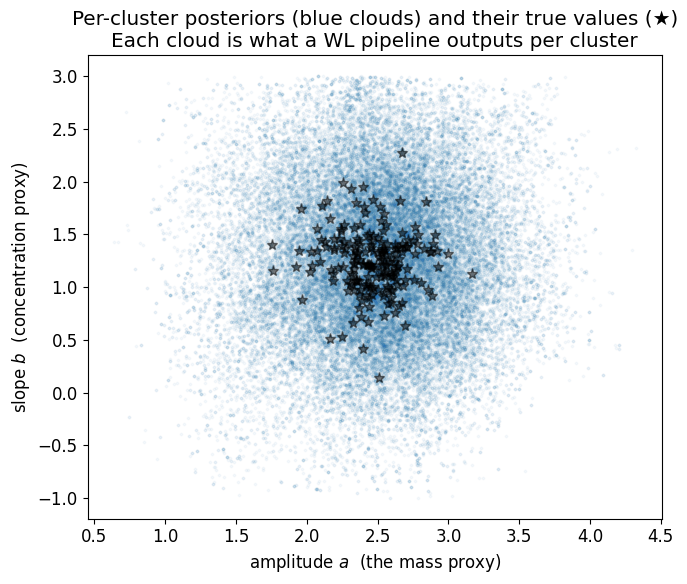

In [17]:
# Look at the per-cluster posteriors -- the raw material we will RECYCLE.
fig, ax = plt.subplots(figsize=(7, 6))
for j in range(n_clusters_pc):
    s = cluster_samples[j]
    ax.scatter(s[::40, 0], s[::40, 1], s=3, alpha=0.04, color="tab:blue")
    ax.plot(theta_true_pc[j, 0], theta_true_pc[j, 1], "k*", ms=8, alpha=0.5)
ax.set_xlabel("amplitude $a$  (the mass proxy)"); ax.set_ylabel("slope $b$  (concentration proxy)")
ax.set_title("Per-cluster posteriors (blue clouds) and their true values (★)\nEach cloud is what a WL pipeline outputs per cluster")
plt.tight_layout(); plt.show()

In [18]:
# pool: concatenate all per-cluster posterior samples for parameter `a` -- one giant bag
pooled_a = cluster_samples[:, :, 0].ravel()
mu_pool   = pooled_a.mean()
tau_pool  = pooled_a.std()
print("naive pool:  mu_a = %.3f   tau_a = %.3f   (truth: mu_a = %.2f, tau_a = %.2f)"
      % (mu_pool, tau_pool, mu_pop[0], s_pop[0]))
print("            -> tau_a is INFLATED: it absorbs the per-cluster posterior width on top of the true scatter.")

naive pool:  mu_a = 2.494   tau_a = 0.514   (truth: mu_a = 2.50, tau_a = 0.25)
            -> tau_a is INFLATED: it absorbs the per-cluster posterior width on top of the true scatter.


In [19]:
a_hat = cluster_samples[:, :, 0].mean(axis=1)    # one number per cluster: the posterior mean of a_j
mu_ols  = a_hat.mean()
tau_ols = a_hat.std()
print("OLS on centers:  mu_a = %.3f   tau_a = %.3f   (truth %.2f, %.2f)"
      % (mu_ols, tau_ols, mu_pop[0], s_pop[0]))
print("                 -> still off: tau_a sees scatter(true theta_j) ⊕ scatter(posterior centers)")

OLS on centers:  mu_a = 2.494   tau_a = 0.414   (truth 2.50, 0.25)
                 -> still off: tau_a sees scatter(true theta_j) ⊕ scatter(posterior centers)


In [21]:
# IMPORTANCE-SAMPLING RECYCLE -- one function = the integral above, evaluated S samples at a time.
# Each line is annotated with the matching piece of the recycling identity.
a_samples = cluster_samples[:, :, 0]                  # theta_j^(s) for the amplitude, shape (N_c, S)

def hyper_logpost(params):                            # params = (mu, log tau)
    mu, lt = params; tau = np.exp(lt)
    if tau > 3: return -np.inf                        # weak hyper-prior bound on tau
    total = 0.0
    for j in range(n_clusters_pc):                    # sum_j  ln [ ... ]
        # population density p(theta|Lambda) evaluated at each stored sample of cluster j:
        pop_density = np.exp(-0.5*((a_samples[j] - mu)/tau)**2) / tau
        # MC integral (1/S) sum_s p(theta^s|Lambda); pi_0 is flat -> cancels and doesn't appear:
        mc_integral = pop_density.mean()
        total += np.log(mc_integral + 1e-300)         # log to avoid underflow
    return total + lt                                 # +log tau = Jacobian for log-tau sampling

mu_a_true, tau_a_true = mu_pop[0], s_pop[0]
hyper_chain = run_mcmc(hyper_logpost, args=(), start=np.array([mu_a_true, np.log(tau_a_true)]),
                       n_walkers=12, n_burn=1500, n_steps=3000)
mu_hat, tau_hat = hyper_chain[:, 0], np.exp(hyper_chain[:, 1])
print("\nrecycle (Attempt 3):  mu_a = %.3f ± %.3f   tau_a = %.3f ± %.3f" %
      (mu_hat.mean(), mu_hat.std(), tau_hat.mean(), tau_hat.std()))
print("                       truth: mu_a = %.2f   tau_a = %.2f" % (mu_a_true, tau_a_true))

   acceptance=0.71 | autocorr ~31 steps | ~1180 independent samples (want >> 1)

recycle (Attempt 3):  mu_a = 2.494 ± 0.029   tau_a = 0.279 ± 0.031
                       truth: mu_a = 2.50   tau_a = 0.25


In [22]:
print("                        mu_a       tau_a    | comment")
print("truth                :  %.3f      %.3f"                       % (mu_a_true, tau_a_true))
print("(1) naive pool       :  %.3f      %.3f    | biased: tau_a inflated by per-cluster scatter" % (mu_pool, tau_pool))
print("(2) OLS on centers   :  %.3f      %.3f    | biased: tau_a inflated by Var(centers)=tau^2+sigma^2" % (mu_ols, tau_ols))
print("(3) recycle (IS)     :  %.3f      %.3f    | CORRECT (uncertainty: ±%.3f, ±%.3f)"
      % (mu_hat.mean(), tau_hat.mean(), mu_hat.std(), tau_hat.std()))

                        mu_a       tau_a    | comment
truth                :  2.500      0.250
(1) naive pool       :  2.494      0.514    | biased: tau_a inflated by per-cluster scatter
(2) OLS on centers   :  2.494      0.414    | biased: tau_a inflated by Var(centers)=tau^2+sigma^2
(3) recycle (IS)     :  2.494      0.279    | CORRECT (uncertainty: ±0.029, ±0.031)


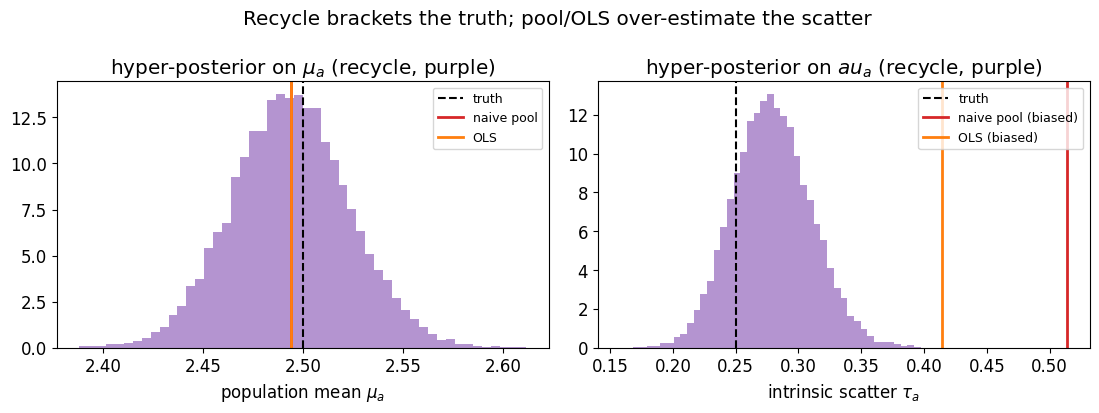

In [23]:
# The hyper-posterior in (mu_a, tau_a) -- our uncertainty on the POPULATION parameters.
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].hist(mu_hat, 50, density=True, color="tab:purple", alpha=0.7); ax[0].axvline(mu_a_true, color="k", ls="--", label="truth")
ax[0].axvline(mu_pool, color="tab:red", lw=2, label="naive pool"); ax[0].axvline(mu_ols, color="tab:orange", lw=2, label="OLS")
ax[0].set_xlabel(r"population mean $\mu_a$"); ax[0].set_title("hyper-posterior on $\mu_a$ (recycle, purple)"); ax[0].legend(fontsize=9)
ax[1].hist(tau_hat, 50, density=True, color="tab:purple", alpha=0.7); ax[1].axvline(tau_a_true, color="k", ls="--", label="truth")
ax[1].axvline(tau_pool, color="tab:red", lw=2, label="naive pool (biased)"); ax[1].axvline(tau_ols, color="tab:orange", lw=2, label="OLS (biased)")
ax[1].set_xlabel(r"intrinsic scatter $\tau_a$"); ax[1].set_title("hyper-posterior on $\tau_a$ (recycle, purple)"); ax[1].legend(fontsize=9)
plt.suptitle("Recycle brackets the truth; pool/OLS over-estimate the scatter"); plt.tight_layout(); plt.show()

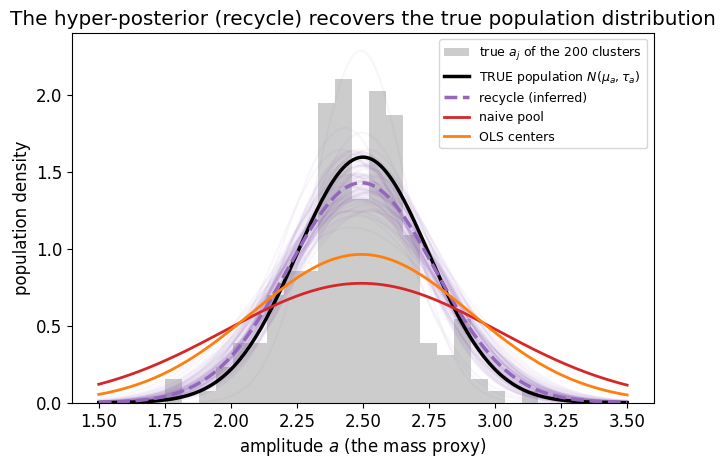

In [24]:
# Does the inferred population distribution match the actual cluster spread?
xx = np.linspace(mu_a_true - 4*tau_a_true, mu_a_true + 4*tau_a_true, 200)
gauss = lambda x, m, s: np.exp(-0.5*((x-m)/s)**2) / (s*np.sqrt(2*np.pi))
plt.figure(figsize=(7.5, 4.8))
plt.hist(theta_true_pc[:, 0], bins=22, density=True, color="0.8", label="true $a_j$ of the %d clusters" % n_clusters_pc)
idx = np.random.randint(len(mu_hat), size=80)
for mh, th in zip(mu_hat[idx], tau_hat[idx]):                              # spaghetti from hyper-posterior
    plt.plot(xx, gauss(xx, mh, th), color="tab:purple", alpha=0.06)
plt.plot(xx, gauss(xx, mu_a_true,    tau_a_true),    "k-",  lw=2.5, label=r"TRUE population $N(\mu_a,\tau_a)$")
plt.plot(xx, gauss(xx, mu_hat.mean(), tau_hat.mean()), "--", color="tab:purple", lw=2.5, label="recycle (inferred)")
plt.plot(xx, gauss(xx, mu_pool,       tau_pool),    "-",  color="tab:red",    lw=2.0, label="naive pool")
plt.plot(xx, gauss(xx, mu_ols,        tau_ols),     "-",  color="tab:orange", lw=2.0, label="OLS centers")
plt.xlabel("amplitude $a$ (the mass proxy)"); plt.ylabel("population density")
plt.title("The hyper-posterior (recycle) recovers the true population distribution"); plt.legend(fontsize=9); plt.show()